Single chart — Layer 8


R² Score: 0.8162
Pearson Correlation Coefficient: 0.9035
Percentage of errors within 2: 72.00%
RMSE: 6.1871


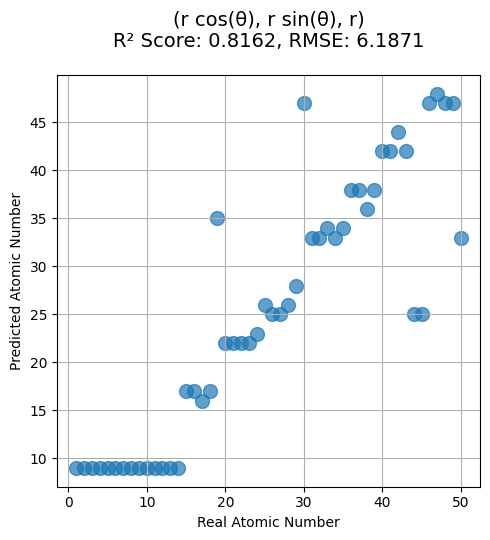

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error

# =====================
# CONFIG — Llama-3.1-8B, layer 8
# =====================
LAYER_IX = 8
MODEL_NAME = "Llama-3.1-8B"
TRANSFORM_NAME = "(r cos(θ), r sin(θ), r)"

file_path = Path("../periodic_table_dataset.csv")
data = pd.read_csv(file_path)

# Try common layer-8 result paths first; fallback to the original path.
candidate_prediction_files = [
    Path(f"../Results/intervention/layer_{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/layer{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/first_number_per_layer_layer{LAYER_IX}.csv"),
    Path("../Results/intervention/first_number_per_layer.csv"),
]

prediction_file = next((p for p in candidate_prediction_files if p.exists()), candidate_prediction_files[-1])
print(f"Using prediction file: {prediction_file}")

atomic_number_data = pd.read_csv(prediction_file, header=None)

# For a per-layer CSV, row index usually equals layer index.
# If the first column stores layer IDs, select the row where col 0 == LAYER_IX.
if 0 in atomic_number_data.columns and (atomic_number_data.iloc[:, 0].astype(str) == str(LAYER_IX)).any():
    row_idx = atomic_number_data.index[atomic_number_data.iloc[:, 0].astype(str) == str(LAYER_IX)][0]
else:
    row_idx = LAYER_IX

atomic_number = pd.to_numeric(atomic_number_data.iloc[row_idx, 1:52], errors='coerce').values
real_atomic_number = data['Atomic Number'][:len(atomic_number)].to_numpy()

atomic_number = np.nan_to_num(atomic_number)

r2 = r2_score(real_atomic_number, atomic_number)
correlation = np.corrcoef(real_atomic_number, atomic_number)[0, 1]
absolute_errors = np.abs(real_atomic_number - atomic_number)
percentage_within_2 = (np.sum(absolute_errors <= 2) / len(absolute_errors)) * 100
rmse = np.sqrt(mean_squared_error(real_atomic_number, atomic_number))

print(f"Model: {MODEL_NAME}")
print(f"Layer: {LAYER_IX}")
print(f"R² Score: {r2:.4f}")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"Percentage of errors within 2: {percentage_within_2:.2f}%")
print(f"RMSE: {rmse:.4f}")

fig, ax = plt.subplots(figsize=(5.8, 5.5))
ax.scatter(real_atomic_number, atomic_number, s=80, alpha=0.7)
ax.plot([1, 50], [1, 50], linestyle='--', alpha=0.8)

ax.set_title(
    f"{MODEL_NAME} — Layer {LAYER_IX}\n{TRANSFORM_NAME}\nR²={r2:.3f}, Abs.err≤2={percentage_within_2:.1f}%",
    fontsize=13,
    pad=14
)
ax.set_xlabel("Real Atomic Number")
ax.set_ylabel("Predicted Atomic Number")
ax.set_xlim(0, 52)
ax.set_ylim(0, 52)
ax.grid(True)
plt.tight_layout()
plt.show()



Combination chart — Layer 8


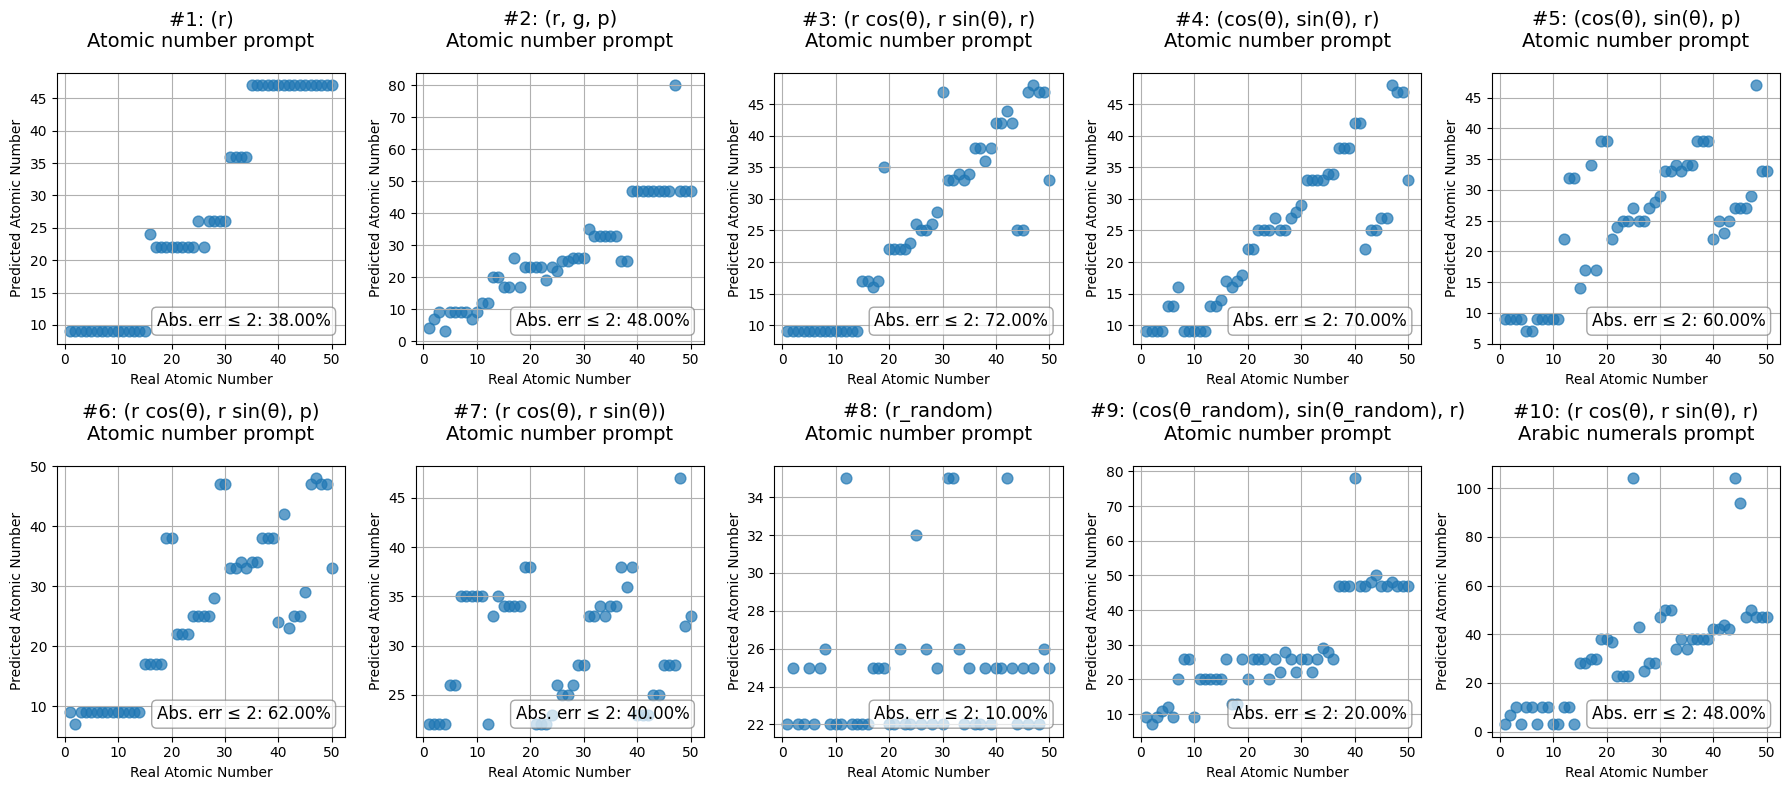

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import r2_score
import math

# =====================
# CONFIG — Llama-3.1-8B, layer 8
# =====================
LAYER_IX = 8
MODEL_NAME = "Llama-3.1-8B"

file_path = Path("../periodic_table_dataset.csv")
data = pd.read_csv(file_path)

candidate_prediction_files = [
    Path(f"../Results/intervention/layer_{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/layer{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/first_number_per_layer_layer{LAYER_IX}.csv"),
    Path("../Results/intervention/first_number_per_layer.csv"),
]
prediction_file = next((p for p in candidate_prediction_files if p.exists()), candidate_prediction_files[-1])
print(f"Using prediction file: {prediction_file}")

atomic_number_data = pd.read_csv(prediction_file, header=None)

# If this CSV stores one row per geometric space for the selected layer,
# keep these row mappings. If your CSV stores one row per layer only,
# use the single-chart cell above instead.
rows = [2, 8, 9, 4, 5, 1, 3, 6, 7, 10]
titles = [
    "#1: (r) - Atomic number prompt",
    "#2: (r, g, p) - Atomic number prompt",
    "#3: (r cos(θ), r sin(θ), r) - Atomic number prompt",
    "#4: (cos(θ), sin(θ), r) - Atomic number prompt",
    "#5: (cos(θ), sin(θ), p) - Atomic number prompt",
    "#6: (r cos(θ), r sin(θ), p) - Atomic number prompt",
    "#7: (r cos(θ), r sin(θ)) - Atomic number prompt",
    "#8: (r_random) - Atomic number prompt",
    "#9: (cos(θ_random), sin(θ_random), r) - Atomic number prompt",
    "#10: (r cos(θ), r sin(θ), r) - Arabic numerals prompt"
]

n_plots = len(rows)
fig, axes = plt.subplots(nrows=2, ncols=math.ceil(n_plots / 2), figsize=(18, 8))
axes = axes.flatten()

for i, row in enumerate(rows):
    if row >= len(atomic_number_data):
        axes[i].axis('off')
        axes[i].set_title(f"{titles[i]}\nRow {row} not found")
        continue

    predicted = pd.to_numeric(atomic_number_data.iloc[row, 1:52], errors='coerce').values
    predicted = np.nan_to_num(predicted)
    real_atomic_number = data['Atomic Number'][:len(predicted)].to_numpy()

    r2 = r2_score(real_atomic_number, predicted)
    absolute_errors = np.abs(predicted - real_atomic_number)
    percentage_within_2 = (np.sum(absolute_errors <= 2) / len(absolute_errors)) * 100

    axes[i].scatter(real_atomic_number, predicted, s=45, alpha=0.7)
    axes[i].plot([1, 50], [1, 50], linestyle='--', alpha=0.7)
    axes[i].set_title(
        f"{titles[i].split(': ')[0]}: {titles[i].split(': ')[1].split(' - ')[0]}\n"
        f"{titles[i].split(' - ')[1]}",
        fontsize=10,
        pad=3
    )
    axes[i].set_xlabel("Real Atomic Number")
    axes[i].set_ylabel("Predicted Atomic Number")
    axes[i].set_xlim(0, 52)
    axes[i].set_ylim(0, 52)
    axes[i].grid(True)
    axes[i].annotate(
        f"R²: {r2:.3f}\nAbs. err ≤ 2: {percentage_within_2:.1f}%",
        xy=(0.95, 0.05),
        xycoords='axes fraction',
        fontsize=9,
        ha='right',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.7)
    )

fig.suptitle(f"Intervention Results — {MODEL_NAME}, Layer {LAYER_IX}", fontsize=15)
plt.tight_layout()
output_dir = Path('../Results/spiral')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f'error_results_layer_{LAYER_IX}.png', dpi=300)
plt.show()



Geometric Shape — Layer 8


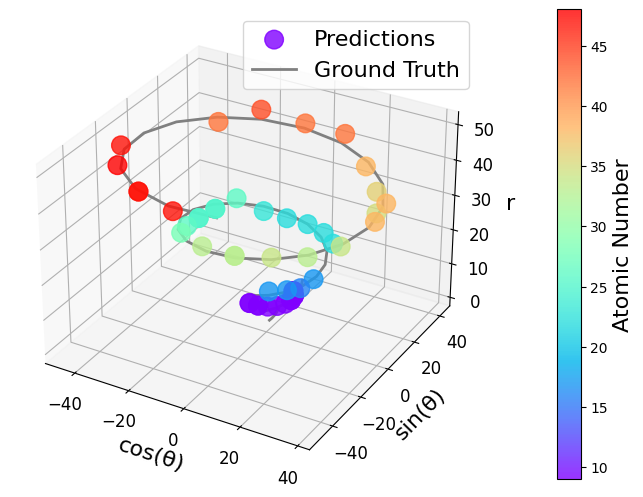

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

# =====================
# CONFIG — Llama-3.1-8B, layer 8
# =====================
LAYER_IX = 8
MODEL_NAME = "Llama-3.1-8B"

file_path = Path("../periodic_table_dataset.csv")
data = pd.read_csv(file_path)

candidate_prediction_files = [
    Path(f"../Results/intervention/layer_{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/layer{LAYER_IX}/first_number_per_layer.csv"),
    Path(f"../Results/intervention/first_number_per_layer_layer{LAYER_IX}.csv"),
    Path("../Results/intervention/first_number_per_layer.csv"),
]
prediction_file = next((p for p in candidate_prediction_files if p.exists()), candidate_prediction_files[-1])
print(f"Using prediction file: {prediction_file}")

atomic_number_data = pd.read_csv(prediction_file, header=None)

# For a per-layer CSV, row index usually equals layer index.
if 0 in atomic_number_data.columns and (atomic_number_data.iloc[:, 0].astype(str) == str(LAYER_IX)).any():
    row_idx = atomic_number_data.index[atomic_number_data.iloc[:, 0].astype(str) == str(LAYER_IX)][0]
else:
    row_idx = LAYER_IX

r_pred = pd.to_numeric(atomic_number_data.iloc[row_idx, 1:52], errors='coerce').values
r_pred = np.nan_to_num(r_pred)

# Match lengths
n = len(r_pred)
group = data['Group'][:n].to_numpy()
atomic_number = data['Atomic Number'][:n].to_numpy()
theta = 2 * np.pi * group / 18

# Ground truth: polar_3d transform
x_gt = atomic_number * np.cos(theta)
y_gt = atomic_number * np.sin(theta)
z_gt = atomic_number

# Prediction: replace r by predicted atomic number
x_pred = r_pred * np.cos(theta)
y_pred = r_pred * np.sin(theta)
z_pred = r_pred.copy()

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x_pred, y_pred, z_pred,
    c=z_pred, cmap='rainbow', s=120, alpha=0.8, label="Predictions"
)

# Avoid drawing lines across large group jumps
group_diff = pd.Series(group).diff().fillna(0).abs().to_numpy()
group_diff_cyclic = np.minimum(group_diff, 18 - group_diff)
break_mask = group_diff_cyclic > 2
z_line = z_gt.astype(float).copy()
z_line[break_mask] = np.nan
ax.plot(x_gt, y_gt, z_line, color='grey', linewidth=2, linestyle='-', label="Ground Truth")

cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.1)
cbar.set_label("Predicted Atomic Number", fontsize=12)

ax.set_title(f"{MODEL_NAME} — Layer {LAYER_IX}: polar_3d intervention", fontsize=13)
ax.set_xlabel("r cos(θ)", fontsize=12)
ax.set_ylabel("r sin(θ)", fontsize=12)
ax.set_zlabel("r", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc="best", fontsize=12)

plt.tight_layout()
plt.show()

output_dir = Path('../Results/spiral')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / f'spiral_plot_layer_{LAYER_IX}.png', dpi=300, bbox_inches='tight')
plt.close(fig)

